In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### Data load and transformation

In [4]:
transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [5]:
dataset_path = "./dataset"

dataset = datasets.ImageFolder(root=dataset_path, transform=image_transforms)
len(dataset)

2300

In [6]:
class_names = dataset.classes
class_names 

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [7]:
train_size = int(0.75*len(dataset))
test_size = len(dataset) - train_size

train_size, test_size

(1725, 575)

In [9]:
from torch.utils.data import random_split

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [10]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [11]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [14]:
images[0].shape

torch.Size([3, 224, 224])

In [15]:
labels[0]

tensor(1)

In [13]:
images[0].permute(1,2,0).shape

torch.Size([224, 224, 3])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5005665].


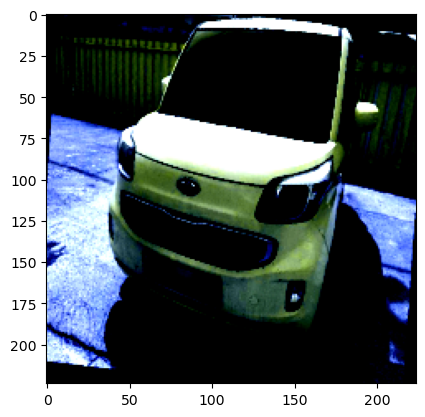

In [16]:
plt.imshow(images[1].permute(1,2,0))
plt.show()

## Model 1: CNN

In [24]:
nums_classes = len(dataset.classes)
nums_classes

6

In [29]:
class CarClassifierCNN(nn.Module):
    def __init__(self, nums_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),          
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
            nn.Flatten(),
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Linear(512, nums_classes)
        )
        
    def forward(self, x):
        x = self.network(x)
        return x

In [36]:
def train_model(model, criterion, optimizer, epochs=5):
    start = time.time()
    
    # Model training
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            
            
            optimizer.zero_grad()
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            if (batch_num+1) % 10 == 0:
                print(f"Batch: {batch_num+1}, Epoch: {epoch+1}, Loss: {loss.item():0.2f}")
            
            running_loss += loss.item() * images.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}], Avg Loss: {epoch_loss:.4f}")

        # Validation
        model.eval()
        correct = 0
        total = 0
        all_labels = []
        all_predictions = []
        
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data,1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())
                
            print(f"*** Validation Accuracy: {100 * correct / total:.2f}% ***")
            
    end = time.time()
    print(f"Execution time: {end - start} seconds")     
    
    return all_labels, all_predictions

In [37]:
model = CarClassifierCNN(nums_classes=nums_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

all_labels, all_predictions = train_model(model, criterion, optimizer, epochs=10)

Batch: 10, Epoch: 1, Loss: 1.76
Batch: 20, Epoch: 1, Loss: 1.76
Batch: 30, Epoch: 1, Loss: 1.50
Batch: 40, Epoch: 1, Loss: 1.60
Batch: 50, Epoch: 1, Loss: 1.63
Epoch [1/10], Avg Loss: 1.7758
*** Validation Accuracy: 33.39% ***
Batch: 10, Epoch: 2, Loss: 1.29
Batch: 20, Epoch: 2, Loss: 1.25
Batch: 30, Epoch: 2, Loss: 1.33
Batch: 40, Epoch: 2, Loss: 1.10
Batch: 50, Epoch: 2, Loss: 1.33
Epoch [2/10], Avg Loss: 1.2529
*** Validation Accuracy: 48.35% ***
Batch: 10, Epoch: 3, Loss: 1.36
Batch: 20, Epoch: 3, Loss: 1.03
Batch: 30, Epoch: 3, Loss: 0.96
Batch: 40, Epoch: 3, Loss: 1.08
Batch: 50, Epoch: 3, Loss: 0.97
Epoch [3/10], Avg Loss: 1.0201
*** Validation Accuracy: 53.74% ***
Batch: 10, Epoch: 4, Loss: 1.04
Batch: 20, Epoch: 4, Loss: 0.95
Batch: 30, Epoch: 4, Loss: 0.89
Batch: 40, Epoch: 4, Loss: 1.02
Batch: 50, Epoch: 4, Loss: 0.94
Epoch [4/10], Avg Loss: 0.9582
*** Validation Accuracy: 54.61% ***
Batch: 10, Epoch: 5, Loss: 0.95
Batch: 20, Epoch: 5, Loss: 1.06
Batch: 30, Epoch: 5, Loss: 0

## Model 2: CNN with regularization

In [41]:
class CarClassifierCNNWithRegularization(nn.Module):
    def __init__(self, nums_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1),  
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), 
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1), 
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),          
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1), 
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
            nn.Flatten(),
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, nums_classes)
        )
        
    def forward(self, x):
        x = self.network(x)
        return x

In [42]:
model = CarClassifierCNNWithRegularization(nums_classes=nums_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

all_labels, all_predictions = train_model(model, criterion, optimizer,  epochs=10)

Batch: 10, Epoch: 1, Loss: 17.13
Batch: 20, Epoch: 1, Loss: 3.85
Batch: 30, Epoch: 1, Loss: 2.17
Batch: 40, Epoch: 1, Loss: 1.61
Batch: 50, Epoch: 1, Loss: 2.01
Epoch [1/10], Avg Loss: 7.9660
*** Validation Accuracy: 42.61% ***
Batch: 10, Epoch: 2, Loss: 1.23
Batch: 20, Epoch: 2, Loss: 1.57
Batch: 30, Epoch: 2, Loss: 1.45
Batch: 40, Epoch: 2, Loss: 1.36
Batch: 50, Epoch: 2, Loss: 1.40
Epoch [2/10], Avg Loss: 1.4648
*** Validation Accuracy: 42.61% ***
Batch: 10, Epoch: 3, Loss: 1.18
Batch: 20, Epoch: 3, Loss: 1.52
Batch: 30, Epoch: 3, Loss: 1.49
Batch: 40, Epoch: 3, Loss: 1.22
Batch: 50, Epoch: 3, Loss: 1.59
Epoch [3/10], Avg Loss: 1.4028
*** Validation Accuracy: 45.57% ***
Batch: 10, Epoch: 4, Loss: 1.22
Batch: 20, Epoch: 4, Loss: 1.34
Batch: 30, Epoch: 4, Loss: 1.30
Batch: 40, Epoch: 4, Loss: 1.52
Batch: 50, Epoch: 4, Loss: 1.48
Epoch [4/10], Avg Loss: 1.3709
*** Validation Accuracy: 51.83% ***
Batch: 10, Epoch: 5, Loss: 1.58
Batch: 20, Epoch: 5, Loss: 1.14
Batch: 30, Epoch: 5, Loss: 

## Model 3: Transfer Learning with EfficientNet

In [52]:
model = models.efficientnet_b0(weights='DEFAULT')
model.classifier[1].in_features

1280

In [43]:
class CarClassifierEfficientNet(nn.Module):
    def __init__(self, nums_classes):
        super().__init__()
        self.model = models.efficientnet_b0(weights='DEFAULT')
        
        for param in self.model.parameters():
            param.requires_grad = False
        
        in_features = self.model.classifier[1].in_features
        
        self.model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, nums_classes)
        )
        
    def forward(self, x):
        x = self.model(x)
        return x 

In [44]:
model = CarClassifierEfficientNet(nums_classes=nums_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

all_labels, all_predictions = train_model(model, criterion, optimizer, epochs=10)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Sarthak/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████████████████████████████████████████████████████████████████████████████████████| 20.5M/20.5M [00:03<00:00, 5.52MB/s]


Batch: 10, Epoch: 1, Loss: 1.70
Batch: 20, Epoch: 1, Loss: 1.40
Batch: 30, Epoch: 1, Loss: 1.45
Batch: 40, Epoch: 1, Loss: 1.27
Batch: 50, Epoch: 1, Loss: 1.21
Epoch [1/10], Avg Loss: 1.4819
*** Validation Accuracy: 58.09% ***
Batch: 10, Epoch: 2, Loss: 1.04
Batch: 20, Epoch: 2, Loss: 1.18
Batch: 30, Epoch: 2, Loss: 1.20
Batch: 40, Epoch: 2, Loss: 1.07
Batch: 50, Epoch: 2, Loss: 0.89
Epoch [2/10], Avg Loss: 1.1357
*** Validation Accuracy: 61.39% ***
Batch: 10, Epoch: 3, Loss: 1.02
Batch: 20, Epoch: 3, Loss: 1.16
Batch: 30, Epoch: 3, Loss: 1.10
Batch: 40, Epoch: 3, Loss: 0.80
Batch: 50, Epoch: 3, Loss: 0.95
Epoch [3/10], Avg Loss: 1.0145
*** Validation Accuracy: 63.48% ***
Batch: 10, Epoch: 4, Loss: 1.04
Batch: 20, Epoch: 4, Loss: 1.03
Batch: 30, Epoch: 4, Loss: 0.97
Batch: 40, Epoch: 4, Loss: 0.89
Batch: 50, Epoch: 4, Loss: 0.77
Epoch [4/10], Avg Loss: 0.9471
*** Validation Accuracy: 64.70% ***
Batch: 10, Epoch: 5, Loss: 0.96
Batch: 20, Epoch: 5, Loss: 0.94
Batch: 30, Epoch: 5, Loss: 0

## Model 4: Transfer learning with ResNet

In [46]:
model = models.resnet50(weights='DEFAULT')
model.fc.in_features

2048

In [55]:
class CarClassifierResNet(nn.Module):
    def __init__(self, nums_classes, dropout_rate=0.5):
        super().__init__()
        self.model = models.resnet50(weights='DEFAULT')
        
        for param in self.model.parameters():
            param.requires_grad = False
                       
            
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.model.fc.in_features, nums_classes)
        )

    def forward(self, x):
        x = self.model(x)
        return x

In [56]:
model = CarClassifierResNet(nums_classes=nums_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

labels, predictions = train_model(model, criterion, optimizer, epochs=10)

Batch: 10, Epoch: 1, Loss: 1.64
Batch: 20, Epoch: 1, Loss: 1.54
Batch: 30, Epoch: 1, Loss: 1.51
Batch: 40, Epoch: 1, Loss: 1.44
Batch: 50, Epoch: 1, Loss: 1.27
Epoch [1/10], Avg Loss: 1.4814
*** Validation Accuracy: 52.52% ***
Batch: 10, Epoch: 2, Loss: 1.24
Batch: 20, Epoch: 2, Loss: 1.23
Batch: 30, Epoch: 2, Loss: 1.11
Batch: 40, Epoch: 2, Loss: 1.07
Batch: 50, Epoch: 2, Loss: 1.20
Epoch [2/10], Avg Loss: 1.1535
*** Validation Accuracy: 59.48% ***
Batch: 10, Epoch: 3, Loss: 1.06
Batch: 20, Epoch: 3, Loss: 1.01
Batch: 30, Epoch: 3, Loss: 0.81
Batch: 40, Epoch: 3, Loss: 0.85
Batch: 50, Epoch: 3, Loss: 0.90
Epoch [3/10], Avg Loss: 1.0162
*** Validation Accuracy: 62.26% ***
Batch: 10, Epoch: 4, Loss: 1.17
Batch: 20, Epoch: 4, Loss: 0.88
Batch: 30, Epoch: 4, Loss: 0.88
Batch: 40, Epoch: 4, Loss: 0.96
Batch: 50, Epoch: 4, Loss: 1.05
Epoch [4/10], Avg Loss: 0.9343
*** Validation Accuracy: 63.65% ***
Batch: 10, Epoch: 5, Loss: 0.81
Batch: 20, Epoch: 5, Loss: 0.92
Batch: 30, Epoch: 5, Loss: 0

## Model 5: Transfer learning with ResNet
#### Unfreezing the layer 4

In [57]:
class CarClassifierResNetUnfreeze(nn.Module):
    def __init__(self, nums_classes, dropout_rate=0.5):
        super().__init__()
        self.model = models.resnet50(weights='DEFAULT')
        
        for param in self.model.parameters():
            param.requires_grad = False
            
        # Unfreeze layer4
        for param in self.model.layer4.parameters():
            param.requires_grad = True            
            
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.model.fc.in_features, nums_classes)
        )

    def forward(self, x):
        x = self.model(x)
        return x

In [58]:
model = CarClassifierResNetUnfreeze(nums_classes=nums_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

labels, predictions = train_model(model, criterion, optimizer, epochs=10)

Batch: 10, Epoch: 1, Loss: 0.93
Batch: 20, Epoch: 1, Loss: 0.57
Batch: 30, Epoch: 1, Loss: 1.01
Batch: 40, Epoch: 1, Loss: 0.57
Batch: 50, Epoch: 1, Loss: 0.51
Epoch [1/10], Avg Loss: 0.8580
*** Validation Accuracy: 71.48% ***
Batch: 10, Epoch: 2, Loss: 0.57
Batch: 20, Epoch: 2, Loss: 0.46
Batch: 30, Epoch: 2, Loss: 0.28
Batch: 40, Epoch: 2, Loss: 0.47
Batch: 50, Epoch: 2, Loss: 0.63
Epoch [2/10], Avg Loss: 0.4625
*** Validation Accuracy: 77.74% ***
Batch: 10, Epoch: 3, Loss: 0.50
Batch: 20, Epoch: 3, Loss: 0.32
Batch: 30, Epoch: 3, Loss: 0.59
Batch: 40, Epoch: 3, Loss: 0.25
Batch: 50, Epoch: 3, Loss: 0.37
Epoch [3/10], Avg Loss: 0.3396
*** Validation Accuracy: 80.52% ***
Batch: 10, Epoch: 4, Loss: 0.15
Batch: 20, Epoch: 4, Loss: 0.13
Batch: 30, Epoch: 4, Loss: 0.22
Batch: 40, Epoch: 4, Loss: 0.36
Batch: 50, Epoch: 4, Loss: 0.97
Epoch [4/10], Avg Loss: 0.2357
*** Validation Accuracy: 79.13% ***
Batch: 10, Epoch: 5, Loss: 0.11
Batch: 20, Epoch: 5, Loss: 0.33
Batch: 30, Epoch: 5, Loss: 0

#### 82 % ACCURACY is achieved with this model

## Model Training & Hyperparameter Tuning

In [62]:
import optuna

class CarClassifierResNetUnfreeze(nn.Module):
    def __init__(self, nums_classes, dropout_rate=0.5):
        super().__init__()
        self.model = models.resnet50(weights='DEFAULT')
        
        for param in self.model.parameters():
            param.requires_grad = False
            
        # Unfreeze layer4
        for param in self.model.layer4.parameters():
            param.requires_grad = True            
            
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.model.fc.in_features, nums_classes)
        )

    def forward(self, x):
        x = self.model(x)
        return x

In [63]:
def objective(trial):
    
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.7)
    
    
    model = CarClassifierResNetUnfreeze(nums_classes=nums_classes, dropout_rate=dropout_rate).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    
    epochs = 3
    start = time.time()
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        # Validation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        
        trial.report(accuracy, epoch)
        
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    end = time.time()
    print(f"Execution time: {end - start} seconds")
    
    return accuracy

In [64]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

[I 2026-10-06 17:55:31,039] A new study created in memory with name: no-name-0f9ecd24-5b62-4631-81bd-933e4159fc1d
[I 2026-10-06 18:14:58,607] Trial 0 finished with value: 76.69565217391305 and parameters: {'lr': 0.00027228619273012906, 'dropout_rate': 0.3174890222077902}. Best is trial 0 with value: 76.69565217391305.


Execution time: 1166.626501083374 seconds


[I 2026-10-06 18:34:28,266] Trial 1 finished with value: 54.95652173913044 and parameters: {'lr': 2.041400033444814e-05, 'dropout_rate': 0.4593005657514814}. Best is trial 0 with value: 76.69565217391305.


Execution time: 1168.857450723648 seconds


[I 2026-10-06 18:52:54,199] Trial 2 finished with value: 77.56521739130434 and parameters: {'lr': 0.0012938250397945808, 'dropout_rate': 0.27217412418004344}. Best is trial 2 with value: 77.56521739130434.


...

[I 2026-10-06 19:56:19,099] Trial 7 pruned. 
[I 2026-10-06 20:02:07,687] Trial 8 pruned. 
[I 2026-10-06 20:07:55,741] Trial 9 pruned. 
[I 2026-10-06 20:19:27,713] Trial 10 pruned. 
[I 2026-10-06 20:31:03,151] Trial 11 pruned. 
[I 2026-10-06 20:48:22,398] Trial 12 finished with value: 80.52173913043478 and parameters: {'lr': 0.0004230441625107306, 'dropout_rate': 0.22369920932383952}. Best is trial 12 with value: 80.52173913043478.


Execution time: 1038.7873873710632 seconds


[I 2026-10-06 20:54:06,489] Trial 13 pruned. 
[I 2026-10-06 20:59:50,006] Trial 14 pruned. 
[I 2026-10-06 21:11:21,123] Trial 15 pruned. 
[I 2026-10-06 21:17:06,415] Trial 16 pruned. 
[I 2026-10-06 21:34:20,239] Trial 17 finished with value: 77.73913043478261 and parameters: {'lr': 0.0007229412139241066, 'dropout_rate': 0.3847610597360015}. Best is trial 12 with value: 80.52173913043478.


Execution time: 1033.3697378635406 seconds


[I 2026-10-06 21:40:07,864] Trial 18 pruned. 
[I 2026-10-06 21:51:35,928] Trial 19 pruned. 


In [65]:
study.best_params

{'lr': 0.0004230441625107306, 'dropout_rate': 0.22369920932383952}

In [66]:
study.best_value

80.52173913043478

In [70]:
study.best_trial

FrozenTrial(number=12, state=<TrialState.COMPLETE: 1>, values=[80.52173913043478], datetime_start=datetime.datetime(2026, 10, 6, 20, 31, 3, 152511), datetime_complete=datetime.datetime(2026, 10, 6, 20, 48, 22, 398153), params={'lr': 0.0004230441625107306, 'dropout_rate': 0.22369920932383952}, user_attrs={}, system_attrs={'tpe:relative_params:0': '{"dropout_rate": 0.22369920932383952, "lr": 0.0004230441625107306}'}, intermediate_values={0: 76.17391304347827, 1: 78.6086956521739, 2: 80.52173913043478}, distributions={'lr': FloatDistribution(high=0.01, log=True, low=1e-05, step=None), 'dropout_rate': FloatDistribution(high=0.7, log=False, low=0.2, step=None)}, trial_id=12, value=None)

### Training with best parameters

In [71]:
model = CarClassifierResNetUnfreeze(nums_classes=nums_classes, dropout_rate=0.223).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0042)

labels, predictions = train_model(model, criterion, optimizer, epochs=10)

Batch: 10, Epoch: 1, Loss: 1.02
Batch: 20, Epoch: 1, Loss: 1.03
Batch: 30, Epoch: 1, Loss: 0.57
Batch: 40, Epoch: 1, Loss: 1.09
Batch: 50, Epoch: 1, Loss: 0.88
Epoch [1/10], Avg Loss: 0.9059
*** Validation Accuracy: 66.43% ***
Batch: 10, Epoch: 2, Loss: 0.66
Batch: 20, Epoch: 2, Loss: 0.75
Batch: 30, Epoch: 2, Loss: 0.42
Batch: 40, Epoch: 2, Loss: 0.40
Batch: 50, Epoch: 2, Loss: 0.50
Epoch [2/10], Avg Loss: 0.5376
*** Validation Accuracy: 67.13% ***
Batch: 10, Epoch: 3, Loss: 0.26
Batch: 20, Epoch: 3, Loss: 0.19
Batch: 30, Epoch: 3, Loss: 0.36
Batch: 40, Epoch: 3, Loss: 0.38
Batch: 50, Epoch: 3, Loss: 0.44
Epoch [3/10], Avg Loss: 0.3732
*** Validation Accuracy: 75.83% ***
Batch: 10, Epoch: 4, Loss: 0.23
Batch: 20, Epoch: 4, Loss: 0.16
Batch: 30, Epoch: 4, Loss: 0.31
Batch: 40, Epoch: 4, Loss: 0.22
Batch: 50, Epoch: 4, Loss: 0.16
Epoch [4/10], Avg Loss: 0.2623
*** Validation Accuracy: 76.87% ***
Batch: 10, Epoch: 5, Loss: 0.25
Batch: 20, Epoch: 5, Loss: 0.15
Batch: 30, Epoch: 5, Loss: 0

## Model Evaluation using Confusion Matrix and Classification Report

In [72]:
from sklearn.metrics import classification_report

report = classification_report(labels, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.82      0.87      0.84       122
           1       0.80      0.72      0.76       107
           2       0.88      0.91      0.89       107
           3       0.82      0.72      0.76        74
           4       0.62      0.76      0.69        76
           5       0.77      0.71      0.74        89

    accuracy                           0.79       575
   macro avg       0.79      0.78      0.78       575
weighted avg       0.79      0.79      0.79       575



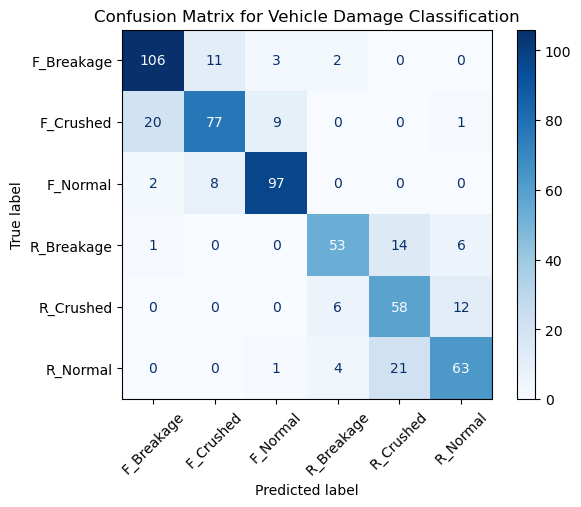

In [86]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

conf_matrix = confusion_matrix(labels, predictions, labels=np.arange(nums_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix for Vehicle Damage Classification")
plt.show()

## Export the model

In [75]:
torch.save(model.state_dict(), 'saved_model.pth')

In [77]:
model.named_parameters

<bound method Module.named_parameters of CarClassifierResNetUnfreeze(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, tr